# 4740 checkpoint 모델

# 3.5.7 Wandb 사용

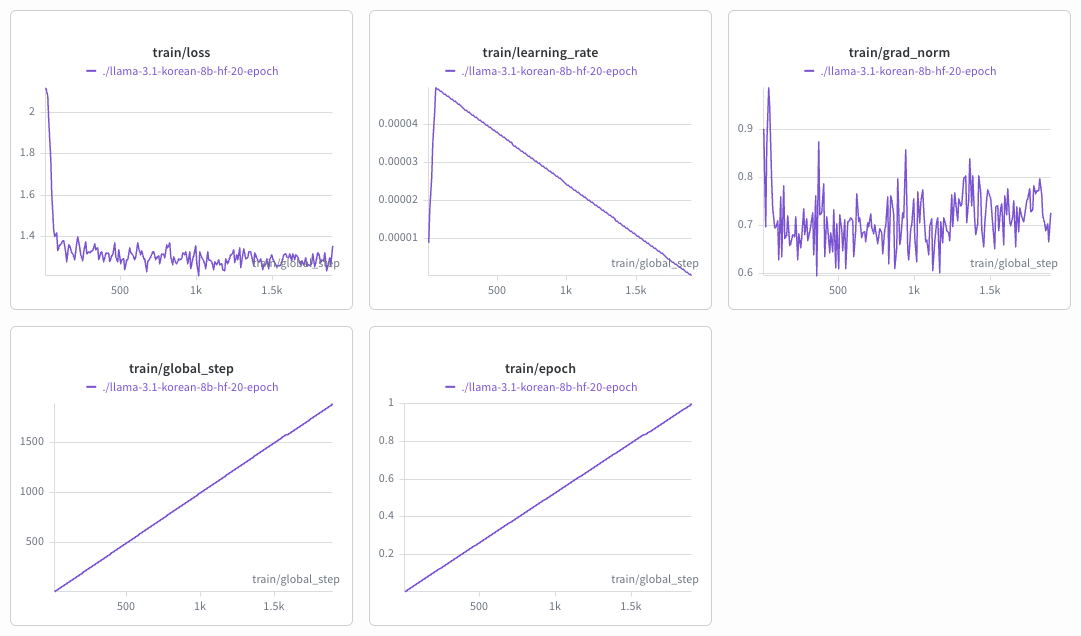

 - train/loss: 학습 과정에서의 손실 함수 값
 - train/grad_norm: 그레이디언트 노름. 안정적으로 유지되는 것이 학습이 안정적으로 진행되고 있음을 보여줌
 - train/global_step: 전체 학습 과정 동안의 스텝 수를 보여줌
 - train/epoch: 에폭 수를 보여줌. 에폭은 전체 데이터셋을 한 번 학습하는 주기
 - train/learning_rate: 학습률

# 3.5.8 학습한 Llama 3.1 모델 테스트

In [ ]:
import os 
import torch 
from random import randint
from datasets import load_dataset
from tqdm.auto import tqdm 

from transformers import (
    AutoModelForCausalLM,
    AutoTokenizer
)

model_name = "./llama-3.1-korean-8b-hf-20-epoch/checkpoint-1896"

# 체크포인트의 파일 경로를 입력하면 모델을 불러옴
model = AutoModelForCausalLM.from_pretrained(
    model_name,
    # 모델의 데이터 형식을 bfloat16으로 지정해 메모리 사용을 줄이고 처리 속도를 높임
    torch_dtype=torch.bfloat16,
    # 모델의 캐시 기능을 꺼서 메모리 사용을 더욱 줄임
    use_cache=False,
    # 사용 가능한 하드웨어에 모델을 자동으로 찾게 설정함
    device_map="auto"
)

test_dataset = load_dataset(
    "json",
    data_files=os.path.join("", "./test_dataset.json"),
    split="train",
)

# AutoTokenizer.from_pretrained로 토크나이저를 불러옴 / use_fast=True로 처리 속도를 높임 (모델이 이해할 수 있는 토큰 형태로 변환)
tokenizer = AutoTokenizer.from_pretrained(model_name, use_fast=True)

# 이 둘을 같게 설정해서, 텍스트 끝을 나타내는 토큰을 패딩에도 사용해 일관성을 유지함
# 일부 LLM은 기본적으로 pad_token이 없기 때문에 배치 학습 시 필요한 padding 토큰을 EOS 토큰으로 대체하여 오류를 방지하고 학습을 안정적으로 진행하기 위해 설정
tokenizer.pad_token = tokenizer.eos_token

# 패딩을 텍스트 오른쪽에 추가함
# 문장의 길이가 서로 다를 때 짧은 문장의 뒤쪽에 padding을 추가하여 입력 길이를 맞춤
tokenizer.padding_side = 'right'

# 테스트 데이터셋을 불러옴
# 테스트용 데이터셋을 불러오고 그중 무작위로 대화 내용을 선택하는 과정
test_dataset = load_dataset("json", 
                            split="train",
                            data_files="test_dataset.json")

random_index = randint(0, len(test_dataset))
messages = test_dataset[random_index]["messages"][:2]

# 이제 채팅 형식을 적용하고 훈련된 모델로 예측
# 생성을 끝낼 토큰을 지정
terminators = [
    tokenizer.eos_token_id,
]

# 대화를 모델이 이해할 수 있는 형식으로 변환
input_ids = tokenizer.apply_chat_template(messages,
                                          add_generation_prompt=True,
                                          return_tensors="pt").to(model.device)

# 실제 응답 생성
outputs = model.generate(
    input_ids,
    # 최대 512개의 새로운 토큰을 생성하도록 함
    max_new_tokens=512,
    # 앞서 정의한 종료 토큰에서 생성을 멈추게 함
    eos_token_id=terminators,
    # 밑에 옵션은 생성의 다양성과 품질의 균형을 맞추는 역할을 함
    do_sample=True,
    temperature=0.7,
    top_p=0.95,
)
response = outputs[0][input_ids.shape[-1]:]
print(f"질문:\n{test_dataset[random_index]['messages'][1]['content']}")
print(f"정답:\n{test_dataset[random_index]['messages'][2]['content']}")
print(f"생성:\n{tokenizer.decode(response,skip_special_tokens=True)}")

Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

Generating train split: 0 examples [00:00, ? examples/s]

The attention mask and the pad token id were not set. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
Setting `pad_token_id` to `eos_token_id`:128009 for open-end generation.
The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
c:\Users\mobile\AppData\Local\mise\installs\python\3.12.13\Lib\site-packages\transformers\models\llama\modeling_llama.py:660: UserWarning: 1Torch was not compiled with flash attention. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\builder\windows\pytorch\aten\src\ATen\native\transformers\cuda\sdp_utils.cpp:555.)
  attn_output = torch.nn.functional.scaled_dot_product_attention(


질문:
지하철 타다 보면 한 구간에서 불이 꺼지는데, 왜 그런가요?
정답:
서울시의 지하철은 직류 1500볼트와 교류 25000볼트를 사용해서 전류 구간을 이동할 때마다 급전 방식이 바뀝니다. 이 때 일시적으로 전동차가 모든 전원을 꺼야 합니다. 그러나 야간이나 지하구간에서 승객의 편의와 범죄 예방을 위해 최소한의 조명은 제공됩니다. 이러한 구간을 '사구간'이라고 하며, 철도청과 지하철공사가 직접 연결된 구간인 경우 사구간 없이 운행됩니다. 이와 같은 전기 구간 변환으로 인해 불이 꺼지는 것입니다.
생성:
1. 지하철 열차는 전기차로, 전기 전원 장치가 없으면 전동차가 움직이지 않습니다. 지하철은 상하행선이 나뉘어져 있기 때문에, 열차가 지하철 선을 따라 전동차가 움직이기 위해서는 전원 공급이 필요합니다. 
2. 그러나 지하철은 전기 전원 장치를 연결하지 않고도 움직일 수 있습니다. 이는 지하철 선이 전류를 전기 전원 장치가 없다고 해도, 기어를 통해 전류를 공급받기 때문입니다. 
3. 전기 전원 장치를 연결하지 않고도 움직일 수 있는 이유는, 지하철 열차에서 사용되는 전기 전원 장치가 전류를 공급하는 역할뿐만 아니라, 전류의 흐름을 제어하는 역할도 합니다. 따라서, 전기 전원 장치를 연결하지 않으면 전류가 흐르지 않아 전동차가 움직이지 않습니다. 
4. 전류의 흐름을 제어하는 역할을 하는 전기 전원 장치가 없으면, 지하철 열차는 전동차로 움직이지 못합니다. 
5. 따라서 지하철에서 한 구간에서 불이 꺼지면, 전기 전원 장치가 없기 때문입니다.


In [2]:
from datasets import load_dataset 
from random import randint


# Load our test dataset
test_dataset = load_dataset("json", 
                            split="train",
                            data_files="test_dataset.json")
random_index = randint(0, len(test_dataset))
messages = test_dataset[random_index]["messages"][:2]

terminators = [
    tokenizer.eos_token_id,
]

# Test on sample 
input_ids = tokenizer.apply_chat_template(messages,
                                          add_generation_prompt=True,
                                          return_tensors="pt").to(model.device)

outputs = model.generate(
    input_ids,
    max_new_tokens=512,
    eos_token_id=terminators,
    do_sample=True,
    temperature=0.7,
    top_p=0.95,
)
response = outputs[0][input_ids.shape[-1]:]
print(f"질문:\n{test_dataset[random_index]['messages'][1]['content']}")
print(f"정답:\n{test_dataset[random_index]['messages'][2]['content']}")
print(f"생성:\n{tokenizer.decode(response,skip_special_tokens=True)}")

The attention mask and the pad token id were not set. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
Setting `pad_token_id` to `eos_token_id`:128009 for open-end generation.


질문:
미국 역사상 최초 부자(父子) 대통령은 누구인가요?
정답:
미국 역사상 부자(父子) 대통령이 두 번 있었습니다. 현재의 조지 W. 부시 대통령과 41대 대통령인 조지 부시를 말합니다. 그리고 이전의 첫 번째 부자 대통령은 존 퀸시 애덤스 대통령입니다. 존 퀸시 애덤스 대통령은 미국 역사상 최초의 부자 대통령으로, 2대 대통령인 아버지 존 애덤스의 아들입니다. 그는 첫 번째 부자 대통령이자, 조지 워싱턴 초대 대통령이 그를 주(駐)뉴질랜드 공사로 발탁한 약 27세의 나이에 첫 정식 외교 임무를 맡았습니다. 그러나 그의 아버지가 대통령이 되자, 자리를 내어주기 위해 그 포지션을 떠났습니다.
생성:
2020년 12월 18일, 미국 역사상 최초로 부자 대통령이 탄생했습니다. 조 바이든 대통령과 그의 아들인 조니 바이든이 부통령으로 선출되면서, 부자 대통령이 탄생했습니다.


In [3]:
from datasets import load_dataset 
from random import randint


# Load our test dataset
test_dataset = load_dataset("json", 
                            split="train",
                            data_files="test_dataset.json")
random_index = randint(0, len(test_dataset))
messages = test_dataset[random_index]["messages"][:2]

terminators = [
    tokenizer.eos_token_id,
]

# Test on sample 
input_ids = tokenizer.apply_chat_template(messages,
                                          add_generation_prompt=True,
                                          return_tensors="pt").to(model.device)

outputs = model.generate(
    input_ids,
    max_new_tokens=512,
    eos_token_id=terminators,
    do_sample=True,
    temperature=0.7,
    top_p=0.95,
)
response = outputs[0][input_ids.shape[-1]:]
print(f"질문:\n{test_dataset[random_index]['messages'][1]['content']}")
print(f"정답:\n{test_dataset[random_index]['messages'][2]['content']}")
print(f"생성:\n{tokenizer.decode(response,skip_special_tokens=True)}")

The attention mask and the pad token id were not set. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
Setting `pad_token_id` to `eos_token_id`:128009 for open-end generation.


질문:
물고기가 물에 빠져서 죽는다는데, 사실인가요? 이유가 무엇인가요?
정답:
민물고기가 바닷물에 빠지면, 죽습니다. 바닷고기 역시 민물에 빠지면 민물고기보다는 조금 늦게 죽습니다. 물고기가 물에 빠져서 죽는 것은 염분 차이를 단시간에 극복하지 못하기 때문입니다. 물고기들은 부레라고 하는 공기 주머니가 뱃속에 있습니다. 이 공기 주머니가 터지면, 물속에서 물고기들의 상대적인 무게가 증가해서 에너지 소비가 늘어 납니다. 또한, 물고기가 부릅뜨릴 때 부레의 작용으로 산소를 공급받기 때문에 부레가 없으면 짧은 시간 내에 산소 부족으로 죽을 수 있습니다. 그리고 미꾸라지, 가물치 등 일부 어종은 부레 대신 보조호흡기관을 가지고 있는데, 이들도 물에 빠지면 보조호흡기관이 제대로 작동하지 않아 익사할 수 있습니다. 하지만 대부분의 물고기는 적당한 수온과 pH를 유지하면 오랫동안 살 수 있으므로 단순히 물에 빠져서 죽는 것은 드물다고 할 수 있습니다.
생성:
1. 물고기가 물에 빠져 죽는 것은 사실입니다. 
물고기는 물에서 산소를 공급받아 산소로 산화수를 만듭니다. 이는 물고기의 몸에 산소가 필요한 이유입니다. 하지만 물속에서 물고기가 죽게 되면, 산소 공급이 중단되기 때문에 산소로 산화수를 만들 수 없습니다. 따라서 물고기가 죽게 되면, 산소 공급이 중단되어 산소로 산화수를 만들 수 없게 됩니다. 

2. 물고기가 죽을 때 산소가 없는 곳으로 가서 죽는 이유는, 물고기가 산소가 없을 때 죽을 가능성이 높기 때문입니다. 물고기는 산소가 없을 때는 죽기 쉬워지기 때문입니다. 

3. 물고기가 죽는 이유는 물속에서 산소 공급이 중단되어 산소로 산화수를 만들 수 없기 때문입니다. 

4. 물고기들이 죽는 이유는 물속에서 산소 공급이 중단되어 산소로 산화수를 만들 수 없기 때문입니다. 

5. 물고기들은 물속에서 산소를 만드는 능력이 매우 뛰어나기 때문에, 물속에서 죽을 가능성이 높습니다. 

6. 물고기가 죽는 이유는 물속에서 산소 공급이 중단되어 산소로 산화수를 만들 수 없

## 최종모델

In [4]:
from datasets import load_dataset 
from random import randint


# Load our test dataset
test_dataset = load_dataset("json", 
                            split="train",
                            data_files="test_dataset.json")
random_index = randint(0, len(test_dataset))
messages = test_dataset[random_index]["messages"][:2]

terminators = [
    tokenizer.eos_token_id,
]

# Test on sample 
input_ids = tokenizer.apply_chat_template(messages,
                                          add_generation_prompt=True,
                                          return_tensors="pt").to(model.device)

outputs = model.generate(
    input_ids,
    max_new_tokens=512,
    eos_token_id=terminators,
    do_sample=True,
    temperature=0.7,
    top_p=0.95,
)
response = outputs[0][input_ids.shape[-1]:]
print(f"질문:\n{test_dataset[random_index]['messages'][1]['content']}")
print(f"정답:\n{test_dataset[random_index]['messages'][2]['content']}")
print(f"생성:\n{tokenizer.decode(response,skip_special_tokens=True)}")

The attention mask and the pad token id were not set. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
Setting `pad_token_id` to `eos_token_id`:128009 for open-end generation.


질문:
컨버전스 마케팅이란 무엇인가요? 예시도 들어서 설명해주세요.
정답:
컨버전스란 여러 기술이나 성능이 하나로 융합되거나 합쳐지는 것을 뜻하는데, 컨버전스 마케팅은 온라인과 오프라인을 결합하여 혼성 소비자를 잡는 전략입니다. 예를 들어 온라인에서 정보를 수집하고, 오프라인 매장에서 구입하는 소비자나 실제 매장에서 가격이나 정보를 수집하고 온라인에서 비교, 구입하는 소비자를 모두 잡는 것입니다. 이러한 전략을 사용하는 브랜드는 많지만, 구체적인 사례를 들기는 어렵습니다.
생성:
1. 컨버전스 마케팅(Conversion Marketing)은 소비자에게 해당 브랜드 제품을 구매하도록 유도하는 마케팅 전략입니다. 
예를 들어, 온라인 쇼핑몰에서 특정 브랜드의 상품을 구매할 때마다 포인트를 받는 것처럼, 고객이 특정 행동을 하게 되면 보상을 제공하는 것입니다. 
2. 컨버전스 마케팅은 마케팅 목표를 달성하기 위한 행동을 유도하는 마케팅 전략입니다. 
예를 들어, 사용자에게 무료로 주기적인 뉴스레터를 제공하고, 뉴스레터를 읽으면서 다른 브랜드의 제품을 구매하도록 유도하는 것입니다. 
3. 컨버전스 마케팅은 제품의 구매를 유도하는 마케팅 전략입니다. 
예를 들어, 사용자가 특정 웹사이트를 방문하면, 해당 브랜드의 제품을 추천해주는 팝업 광고를 보여주는 것입니다. 
4. 컨버전스 마케팅은 브랜드와 사용자 간의 상호 작용을 유도하는 마케팅 전략입니다. 
예를 들어, 사용자가 특정 웹사이트를 방문하면, 브랜드의 제품에 대한 정보를 제공하고, 사용자가 제품에 대한 정보를 받은 후, 사용자가 구매를 할 수 있도록 유도하는 것입니다. 
5. 컨버전스 마케팅은 사용자가 특정 행동을 하도록 유도하는 마케팅 전략입니다. 
예를 들어, 사용자가 특정 웹사이트를 방문하면, 해당 브랜드의 제품에 대한 정보를 제공하고, 사용자가 제품에 대한 정보를 받은 후, 사용자가 구매를 할 수 있도록 유도하는 것입니다.


In [29]:
from datasets import load_dataset 
from random import randint


# Load our test dataset
test_dataset = load_dataset("json", 
                            split="train",
                            data_files="test_dataset.json")
random_index = randint(0, len(test_dataset))
messages = test_dataset[random_index]["messages"][:2]

terminators = [
    tokenizer.eos_token_id,
]

# Test on sample 
input_ids = tokenizer.apply_chat_template(messages,
                                          add_generation_prompt=True,
                                          return_tensors="pt").to(model.device)

outputs = model.generate(
    input_ids,
    max_new_tokens=512,
    eos_token_id=terminators,
    do_sample=True,
    temperature=0.7,
    top_p=0.95,
)
response = outputs[0][input_ids.shape[-1]:]
print(f"질문:\n{test_dataset[random_index]['messages'][1]['content']}")
print(f"정답:\n{test_dataset[random_index]['messages'][2]['content']}")
print(f"생성:\n{tokenizer.decode(response,skip_special_tokens=True)}")

The attention mask and the pad token id were not set. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
Setting `pad_token_id` to `eos_token_id`:128009 for open-end generation.


질문:
해바라기씨를 과다 복용하면 문제가 될까요? 그리고 임산부는 왜 많이 못 먹게 되는 걸까요? 
사람들이 해바라기씨를 적당한 양으로 먹을 때는 건강에 매우 좋다는데, 과다 복용을 하면 살이 찌거나 얼굴이 번들거리는 등 부작용이 있을까요? 그리고 임산부들은 해바라기씨를 왜 많이 못 먹게 되는 걸까요?
정답:
해바라기씨를 적당히 섭취할 때는 영양에 매우 좋은 식품 중 하나입니다. 해바라기씨는 다른 식물성 기름보다 비교적 많은 비타민 A, E가 함유되어 있어 단백질, 지방 등 열량 영양소의 흡수량을 높여 주고 질병에 대한 저항력도 높여 주는 역할을 합니다. 그래서 보건식품으로 권장되는 식품입니다. 해바라기씨의 기름은 다른 기름보다 비타민 함량이 많아 다른 식용유보다 보건식품으로 권장되는 식품입니다. 해바라기씨에는 칼륨, 칼슘, 철분 등의 무기질과 일반 곡류가 정제 과정에서 상실하기 쉬운 비타민 B 복합체가 풍부하기때문에 고혈압이나 신경과민에 탁월한 효과를 보이므로 고혈압이나 신경과민이 원인이 되는 동맥경화에 좋아요. 

하지만 과도한 섭취는 부작용을 일으킬 수 있습니다. 해바라기씨에는 지방이 많으므로, 과도하게 섭취할 경우 살이 찌거나 피부가 염증을 일으키는 등의 문제가 발생할 수 있습니다. 또한 해바라기씨는 지질성 반건조기 때문에 먹으면 피부가 가렵거나 따가울 수 있습니다. 그러므로 적당한 양 섭취가 필요합니다. 

임신부가 너무 많이 먹으면 안 되는 이유는 해바라기씨에 들어있는 카페인 때문입니다. 카페인의 경우, 임신 증상 중 일부를 악화시킬 수 있을 뿐 아니라, 태아에게도 안 좋은 영향을 미칠 수 있기 때문입니다. 그러므로 임산부는 적당한 양을 섭취하는 것이 좋습니다.
생성:
1. 해바라기씨를 과다 복용하면 문제가 될 수 있습니다. 과다 복용으로 인해 소화장애나 변비 등이 발생할 수 있으며, 매우 극소량이라도 중독 증상이 나타날 수 있습니다. 따라서 적당량을 유지하는 것이 좋습니다. 
2. 임신한 여성은 해바라기씨를 많이 먹지 않는 것이 좋습니다. 해바라기

In [13]:
from datasets import load_dataset 
from random import randint


# Load our test dataset
test_dataset = load_dataset("json", 
                            split="train",
                            data_files="test_dataset.json")
random_index = randint(0, len(test_dataset))
messages = test_dataset[random_index]["messages"][:2]

terminators = [
    tokenizer.eos_token_id,
]

# Test on sample 
input_ids = tokenizer.apply_chat_template(messages,
                                          add_generation_prompt=True,
                                          return_tensors="pt").to(model.device)

outputs = model.generate(
    input_ids,
    max_new_tokens=512,
    eos_token_id=terminators,
    do_sample=True,
    temperature=0.7,
    top_p=0.95,
)
response = outputs[0][input_ids.shape[-1]:]
print(f"질문:\n{test_dataset[random_index]['messages'][1]['content']}")
print(f"정답:\n{test_dataset[random_index]['messages'][2]['content']}")
print(f"생성:\n{tokenizer.decode(response,skip_special_tokens=True)}")

The attention mask and the pad token id were not set. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
Setting `pad_token_id` to `eos_token_id`:128009 for open-end generation.


질문:
쥐며느리란 명칭의 유래는 무엇인가요?
쥐며느리는 영어로 Woodlouse로 번역되기도 하는데, 이 이름의 유래는 무엇인가요?
정답:
쥐며느리란 말은 쥐의 며느리라는 뜻입니다. 쥐며느리는 평지의 낙엽이나 돌 밑, 집 주위의 쓰레기 더미 등 습한 곳에 무리 지어 삽니다. 이러한 서식지로 인해 쥐와 함께 살아가는 경우도 많은데, 쥐를 두려워하여 쥐가 지나가면 죽은 척을 하며 자신의 몸을 보호합니다. 이러한 행동이 가련한 모습의 '시어머니 앞에서 꼼짝 못하는 가련한 며느리'의 모습과 닮아서 붙은 이름입니다. 이러한 이름에 대한 다른 표현으로는 서부(鼠婦), 서고(鼠姑)라고도 합니다.
생성:
1. 쥐며느리란 ‘쥐’와 ‘며느리’라는 단어가 합쳐진 단어입니다.
2. ‘쥐’는 동물 쥐를 가리키는 단어이며,
‘며느리’는 여자아이를 일컫는 단어입니다.
3. 따라서, 쥐며느리는 ‘쥐가 며느리를 같다’는 의미를 가진 단어입니다.
4. 영어로 Woodlouse로 번역되기도 하는데, 이는 쥐의 종류 중 하나인 나무쥐를 가리키는 단어이기 때문입니다.
5. 나무쥐는 털이 흰색이며 몸체가 가늘고 길며, 꼬리가 털로 덮여 있습니다.
6. 따라서, 쥐며느리의 모습이 나무쥐와 유사하여 영어로 Woodlouse로 번역되기도 합니다.


In [26]:
from datasets import load_dataset 
from random import randint


# Load our test dataset
test_dataset = load_dataset("json", 
                            split="train",
                            data_files="test_dataset.json")
random_index = randint(0, len(test_dataset))
messages = test_dataset[random_index]["messages"][:2]

terminators = [
    tokenizer.eos_token_id,
]

# Test on sample 
input_ids = tokenizer.apply_chat_template(messages,
                                          add_generation_prompt=True,
                                          return_tensors="pt").to(model.device)

outputs = model.generate(
    input_ids,
    max_new_tokens=512,
    eos_token_id=terminators,
    do_sample=True,
    temperature=0.7,
    top_p=0.95,
)
response = outputs[0][input_ids.shape[-1]:]
print(f"질문:\n{test_dataset[random_index]['messages'][1]['content']}")
print(f"정답:\n{test_dataset[random_index]['messages'][2]['content']}")
print(f"생성:\n{tokenizer.decode(response,skip_special_tokens=True)}")

The attention mask and the pad token id were not set. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
Setting `pad_token_id` to `eos_token_id`:128009 for open-end generation.


질문:
'높이는'과 '높히는' 중 올바른 맞춤법은 어떤 것이며 그 이유는 무엇인가요?
정답:
한국어 화자들이 '높이는'을 [노피는]이라고 발음합니다. 그러나 '높이는'과 '높히는' 중 어느 것이 올바른 맞춤법인지는 발음만으로 알 수 없습니다. 따라서 표기를 기준으로 판정해야 합니다. '높이는'은 형용사 '높다'의 사동접미사 '-이-'와 결합하여 만들어진 단어입니다. 이에 따라 '높이는'이 올바른 표기입니다. '높히는'은 음절의 끝소리 규칙과 거센 소리 되기 현상에 따라 발음상으로 [노피는]과 동일한 소리를 발생시키기 때문에 혼동될 수 있습니다. 다른 단어들과 구별하며 문장 내에서 높이에 대한 동작을 나타내고자 한다면 '높이는'을 사용해야 합니다.
생성:
1. '높이'는 고유명사이며, '높이'로 쓰여야 합니다. 
2. '높이'가 고유명사인 경우, 비교적이나 SUPERLATIVE 형태로 쓰일 수 없습니다. 
3. 만약 '높이'가 일반 명사인 경우, 비교적이나 SUPERLATIVE 형태로 쓰일 수 있습니다.
4. '높이'가 일반 명사인 경우, 다음과 같이 사용할 수 있습니다.
    - 비교적: a. 높이 < 기둥의 높이 b. 기둥의 높이 < 서장의 높이
    - SUPERLATIVE: a. 이 산은 높이 가장 높다 b. 이 산은 가장 높이 높다
5. '높이'가 고유명사인 경우, 다음과 같이 사용할 수 있습니다.
    - 비교적: a. 높이 < 기둥의 높이 b. 기둥의 높이 < 서장의 높이
    - SUPERLATIVE: a. 이 산은 높이 가장 높다 b. 이 산은 가장 높이 높다


In [15]:
from datasets import load_dataset 
from random import randint


# Load our test dataset
test_dataset = load_dataset("json", 
                            split="train",
                            data_files="test_dataset.json")
random_index = randint(0, len(test_dataset))
messages = test_dataset[random_index]["messages"][:2]

terminators = [
    tokenizer.eos_token_id,
]

# Test on sample 
input_ids = tokenizer.apply_chat_template(messages,
                                          add_generation_prompt=True,
                                          return_tensors="pt").to(model.device)

outputs = model.generate(
    input_ids,
    max_new_tokens=512,
    eos_token_id=terminators,
    do_sample=True,
    temperature=0.7,
    top_p=0.95,
)
response = outputs[0][input_ids.shape[-1]:]
print(f"질문:\n{test_dataset[random_index]['messages'][1]['content']}")
print(f"정답:\n{test_dataset[random_index]['messages'][2]['content']}")
print(f"생성:\n{tokenizer.decode(response,skip_special_tokens=True)}")

The attention mask and the pad token id were not set. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
Setting `pad_token_id` to `eos_token_id`:128009 for open-end generation.


질문:
무궁화는 언제 우리나라 꽃으로 정해졌으며, 누가 정한 것일까요?
정답:
무궁화는 예로부터 우리나라에서 자라는 꽃으로, 한국인들은 그 국화라는 것을 알고 있지만, 그 근거는 명확하지 않습니다. 고대 조선 시대부터 이미 존재하며, 조선 시대에도 국내외로 전파되었습니다. 1928년 발행된 한 국화 도감에서도 국민 대다수의 선택으로 국화로 지정되었다고 합니다. 무궁화는 일제 강점기에도 애환을 나누며 우리 민족의 꽃으로 자리잡게 되었습니다.
생성:
1970년 8월 15일 대한민국 정부수립 10주년을 기념하여 국화로 지정된 것입니다. 무궁화는 예로부터 우리 민족의 대표적인 국화로서 사랑 받던 꽃이었습니다. 국화로 지정되기 이전에도 무궁화는 우리나라의 대표적인 국화로 여겨져왔으며, 우리나라를 대표하는 꽃으로 사용되어왔습니다.


In [24]:
from datasets import load_dataset 
from random import randint


# Load our test dataset
test_dataset = load_dataset("json", 
                            split="train",
                            data_files="test_dataset.json")
random_index = randint(0, len(test_dataset))
messages = test_dataset[random_index]["messages"][:2]

terminators = [
    tokenizer.eos_token_id,
]

# Test on sample 
input_ids = tokenizer.apply_chat_template(messages,
                                          add_generation_prompt=True,
                                          return_tensors="pt").to(model.device)

outputs = model.generate(
    input_ids,
    max_new_tokens=512,
    eos_token_id=terminators,
    do_sample=True,
    temperature=0.7,
    top_p=0.95,
)
response = outputs[0][input_ids.shape[-1]:]
print(f"질문:\n{test_dataset[random_index]['messages'][1]['content']}")
print(f"정답:\n{test_dataset[random_index]['messages'][2]['content']}")
print(f"생성:\n{tokenizer.decode(response,skip_special_tokens=True)}")

The attention mask and the pad token id were not set. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
Setting `pad_token_id` to `eos_token_id`:128009 for open-end generation.


질문:
성이나 이름 뒤에 '씨' 띄어쓰기 질문입니다. 

만약 '홍길동 씨'라고 쓰는 것이 맞다고 하는데, 다른 곳을 보니까 성 뒤에 붙는 경우 예를 들어 '홍씨'나 '홍 씨'와 같은 경우 의미가 달라진다고 들은 것 같아요. 홍씨라는 것은 '홍'이라는 성을 가진 사람을 말하는 것이고, 홍 씨의 경우는 전체적인 성을 지칭할 때 쓰는 거라 들은 것 같은데 맞는 건가요?
정답:
한 마디로, 의존명사 '씨'(띄어 쓰는)는 특정인, 접미사 '씨'(붙여 쓰는)는 성씨 그 자체 또는 해당 가문의 뜻입니다. 따라서, '홍길동 씨'라는 표현은 맞습니다. '홍 씨' 또는 '홍씨'는 전체적인 성을 지칭하는 의미로 쓰이기 때문에, 예를 들어 '홍씨 성을 가진 홍길동 씨'는 맞지만, '홍 씨 집안'이라고 하면 이는 특정인(홍길동)의 집안이라는 의미가 아니라, 홍씨 가문이라는 의미가 됩니다. 따라서, '홍씨 집안 아들이다'와 '홍 씨 집안 아들이다' 모두 가능합니다.
생성:
1. 성이나 이름 뒤에 '씨'를 붙이는 경우

'씨'는 성이나 이름의 일부를 나타내는 접미사입니다. 일반적으로 '홍길동 씨'와 같은 표현은 올바른 표현이 아닙니다. 홍길동이라는 이름의 소유자에 대한 정보를 담고 있는 것이기 때문입니다. 

2. 성 뒤에 '씨'가 붙는 경우
'홍씨'나 '홍 씨'와 같은 표현은 성 '홍'을 가리키는 것입니다. 여기서 '씨'는 성을 가리키는 것이 아니라, 이름의 일부를 가리키는 접미사입니다. 

3. 이름 뒤에 '씨'가 붙는 경우
'홍길동씨'와 같은 표현은 이름 '홍길동'의 소유자에 대한 정보를 담고 있는 것입니다. 이 경우 '씨'는 이름의 일부를 가리키는 접미사로 사용됩니다.

따라서, 성이나 이름 뒤에 '씨'가 붙는 경우, 그 표현은 해당 인물의 이름 혹은 성을 가리키는 것이 아닌, 일부를 나타내는 접미사로 사용된 것입니다. 

 참고사항
'씨' 외에도 '-son'이나 '-dough'와 같은 이름 끝도 일종의 접미사로 사용됩니다. 이러한 접미사를 사용한 이름은 영어식 이름을 따른 경

In [25]:
random_index = randint(0, len(test_dataset))
messages = test_dataset[random_index]["messages"][:2]

terminators = [
    tokenizer.eos_token_id,
]

# Test on sample 
input_ids = tokenizer.apply_chat_template(messages,
                                          add_generation_prompt=True,
                                          return_tensors="pt").to(model.device)

outputs = model.generate(
    input_ids,
    max_new_tokens=512,
    eos_token_id=terminators,
    do_sample=True,
    temperature=0.7,
    top_p=0.95,
)
response = outputs[0][input_ids.shape[-1]:]
print(f"질문:\n{test_dataset[random_index]['messages'][1]['content']}")
print(f"정답:\n{test_dataset[random_index]['messages'][2]['content']}")
print(f"생성:\n{tokenizer.decode(response,skip_special_tokens=True)}")

The attention mask and the pad token id were not set. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
Setting `pad_token_id` to `eos_token_id`:128009 for open-end generation.


질문:
전화기 콘센트는 왜 구멍이 4개일까요? 

전자제품의 대부분이 2개의 구멍으로 된 일반 콘센트를 사용한다면, 전화기 콘센트는 왜 4개의 구멍을 가지고 있을까요?
정답:
전화기의 콘센트는 예비 꼭지의 역할을 하기 때문입니다. 전화기 플러그는 4개의 구멍으로 되어있는데, 이렇게 설계된 이유는 전화기의 특수한 성질 때문입니다. 4개의 구멍을 이용하면 전화기 플러그가 더 잘 끼워질 수 있기 때문입니다. 

하지만, 전화기 플러그가 4개인 이유는 그것뿐만은 아닙니다. 일반적으로 한 회선에서 두개의 전화를 사용할 수 있도록 하기 위해 4개 중 두 개의 구멍을 하나의 전화 선으로 할당하여 사용합니다. 따라서 4개의 구멍 중 2개만 사용하면 되지만, 이러한 이유로 인해 전화기 콘센트는 구멍이 4개인 것입니다. 

물론, 우리나라에서는 이러한 방식으로 사용하지 않기 때문에, 4개의 구멍 중 두 개 선을 사용하지 않으면, 인터넷 연결할 때나 다른 용도로 사용할 수도 있습니다.
생성:
2극용 콘센트는 1극이 위쪽에 1개씩 있는 것이고, 3극용 콘센트는 1극이 위쪽에 1개, 나머지 2극이 아래쪽에 1개씩 있는 것입니다. 전압이 1상 4선식으로 되어 있는 전화기의 경우, 위쪽에 1극이 1개, 아래쪽에 2극이 1개씩 있는 3극 콘센트를 사용합니다. 하지만, 전화기는 대기전력이 있기 때문에 콘센트에 전류가 흐르는 상태가 계속 되어야 합니다. 따라서 전류가 항상 흐를 수 있도록 4개의 구멍이 있는 것입니다. 콘센트는 전화기만 사용하는 것이 아니라 다른 전자제품에서도 사용되는데, 이 경우는 2개의 구멍으로 된 일반 콘센트를 사용합니다.


In [33]:
from pydantic import BaseModel
from openai import OpenAI
import os

# OpenAI 클라이언트 초기화
client = OpenAI(api_key="Your_OpenAI_API_KEY")

class Criterion(BaseModel):
    score: int
    explanation: str

class Evaluation(BaseModel):
    relevance: Criterion
    accuracy: Criterion
    completeness: Criterion
    clarity: Criterion
    similarity: Criterion
    average_score: float

def evaluate_qa_model(question: str, reference_answer: str, model_answer: str) -> Evaluation:
    prompt = f"""
질문: {question}
참조 답변: {reference_answer}
모델 생성 답변: {model_answer}

위의 질문에 대한 두 답변을 비교 평가해주세요. 다음 기준에 따라 1-10점 사이의 점수를 매겨주세요:
1. 관련성: 모델의 답변이 질문과 얼마나 관련이 있는가?
2. 정확성: 모델이 제공한 정보가 참조 답변과 비교하여 얼마나 정확한가?
3. 완전성: 모델의 답변이 질문에 대해 얼마나 포괄적인가?
4. 명확성: 모델의 답변이 얼마나 명확하고 이해하기 쉬운가?
5. 유사성: 모델의 답변이 참조 답변과 얼마나 유사한가?

각 기준에 대한 점수와 간단한 설명을 제공해주세요. 마지막으로 전체 평균 점수를 계산해주세요.
"""

    completion = client.beta.chat.completions.parse(
        model="gpt-4o-mini",  # 또는 사용 가능한 최신 모델
        messages=[
            {"role": "system", "content": "귀하는 QA 모델 응답을 평가하는 임무를 맡은 AI 어시스턴트입니다."},
            {"role": "user", "content": prompt}
        ],
        response_format=Evaluation
    )

    return completion

# 사용 예시
if __name__ == "__main__":
    question = "인공지능의 윤리적 고려사항은 무엇인가요?"
    reference_answer = "인공지능의 주요 윤리적 고려사항에는 1) 프라이버시 보호: 개인 정보의 수집, 처리, 저장에 관한 문제, 2) 알고리즘 편향성 방지: 인종, 성별, 연령 등에 대한 차별 방지, 3) 투명성 확보: AI 의사결정 과정의 설명 가능성, 4) 책임성 명확화: AI 시스템의 오류나 해악에 대한 책임 소재, 5) 안전성과 보안: AI 시스템의 안전한 작동과 외부 공격으로부터의 보호, 6) 인간 통제: AI가 인간의 통제를 벗어나지 않도록 하는 것 등이 있습니다. 이러한 요소들은 AI 기술이 사회에 미치는 영향을 고려하여 신중하게 다루어져야 하며, 법적, 제도적 장치를 통해 관리되어야 합니다."
    
    model_answer = "인공지능의 윤리적 고려사항에는 프라이버시 보호, 알고리즘 편향성 방지, 투명성 확보, 책임성 명확화 등이 있습니다. 이러한 요소들은 AI 기술이 사회에 미치는 영향을 고려하여 신중하게 다루어져야 합니다."

    evaluation = evaluate_qa_model(question, reference_answer, model_answer)
    print(evaluation)

ParsedChatCompletion[Evaluation](id='chatcmpl-9uKl08I70Rm06lDF8pYzOj6ElC5vJ', choices=[ParsedChoice[Evaluation](finish_reason='stop', index=0, logprobs=None, message=ParsedChatCompletionMessage[Evaluation](content='{"relevance":{"score":9,"explanation":"모델의 답변은 인공지능의 윤리적 고려사항에 관한 질문에 직접적으로 관련된 주요 요소들을 언급하고 있다."},"accuracy":{"score":9,"explanation":"제공된 정보는 참조 답변과 일치하고, 주요 윤리적 고려사항을 정확하게 설명하고 있다."},"completeness":{"score":7,"explanation":"모델의 답변은 몇 가지 주요 윤리적 고려사항을 나열했지만, 참조 답변에 비해 다소 포괄성이 떨어진다."},"clarity":{"score":8,"explanation":"모델의 답변은 전반적으로 명확하고 이해하기 쉽지만, 일부 약간의 세부사항이 부족할 수 있다."},"similarity":{"score":6,"explanation":"모델의 답변은 참조 답변에서 제공한 내용을 기반으로 하였지만, 구체적인 사항이나 모든 항목이 포함되지 않았다."},"average_score":7.8}', refusal=None, role='assistant', function_call=None, tool_calls=[], parsed=Evaluation(relevance=Criterion(score=9, explanation='모델의 답변은 인공지능의 윤리적 고려사항에 관한 질문에 직접적으로 관련된 주요 요소들을 언급하고 있다.'), accuracy=Criterion(score=9, explanation='제공된 정보는 참조 답변과 일치하고, 주요 윤리적 고려사항을 정확하게 설명하고 있다.'), com

In [34]:
print(evaluation.choices[0].message.parsed.relevance.dict())

{'score': 9, 'explanation': '모델의 답변은 인공지능의 윤리적 고려사항에 관한 질문에 직접적으로 관련된 주요 요소들을 언급하고 있다.'}
